## Overall Structure 
1. Introduction
2. Data Loading , Understanding & Cleaning
3. RFM Feature Engineering
4. Exploratory Data Analysis
5. Data Preprocessing
6. KMeans Modeling
7. Cluster Analysis & Business Insights
8. PCA Visulation
9. Conclusion

#

## 1.Introduction 

**Business Context:**
- Businesses with thousands of customers cannot treat everyone the same — different customers have different loyalty levels, spending habits, and churn risks
- Customer segmentation groups customers into meaningful clusters that were previously unknown — enabling personalized offers, targeted discounts, and marketing strategies that fit each customer profile

**Objective:**
- Build an unsupervised machine learning pipeline to segment customers based on purchasing behavior
- Use RFM analysis — Recency, Frequency, Monetary — to characterize each customer by three behavioral dimensions
- Apply K-Means clustering to discover natural groups like high-value loyalists, frequent buyers, and at-risk customers

**Dataset:**
- Online Retail dataset — 1,067,371 real transactions from a UK-based online retailer between 2010 and 2011

**Key Difference From Supervised Learning:**
- No target variable — no right or wrong answer to measure against
- The model discovers hidden structure in the data
- Quality evaluated using Elbow Method and Silhouette Score

**Expected Output:**
- Distinct customer segments with clear behavioral profiles
- Concrete marketing recommendations per segment to improve retention, personalize experience, and allocate resources effectively


## 2. Data Loading , Understanding & Cleaning

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [2]:
df = pd.read_csv("online_retail.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.shape

(1067371, 8)

In [4]:
df.dtypes

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

In [5]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

### Dataset Overview
The raw dataset contains **1,067,371 transactions across 8 features** — representing real UK online retail purchases from 2010-2011.

### Feature Descriptions

| Feature | Description |
|---|---|
| `Invoice` | Unique transaction ID |
| `StockCode` | Alphanumeric product identifier |
| `Description` | Product name |
| `Quantity` | Number of items purchased |
| `InvoiceDate` | Transaction timestamp — requires conversion to datetime |
| `Price` | Unit price per item |
| `Customer ID` | Unique customer identifier |
| `Country` | Customer's country of purchase |

### Data Quality Observations
- **Data types:** Mostly object (string) format — InvoiceDate requires conversion to datetime before Recency calculation
- **Missing values:** Heavily concentrated in `Customer ID` — critical for RFM analysis — and `Description` — non-critical
- **Alphanumeric StockCodes:** Letters mixed into product codes indicate non-product entries such as postage charges, fees, and cancellations — require removal before analysis

### Immediate Cleaning Challenges
- **Missing Customer IDs** — transactions cannot be attributed to a customer without this field — rows must be dropped
- **Non-standard StockCodes** — operational entries disguised as products will distort behavioral modeling if left uncleaned
- **Cancelled orders** — identifiable by negative quantities and "C" prefix on Invoice — must be removed to preserve accurate Monetary and Frequency values


In [6]:
non_standard_mask = ~df["StockCode"].astype(str).str.contains(r"^\d", na=False)
non_standard_count = df[non_standard_mask].shape[0]

print(f"Total rows with non-standard StockCodes: {non_standard_count}")
print("\nUnique non-standard codes found:")
print(df[non_standard_mask]["StockCode"].value_counts())

Total rows with non-standard StockCodes: 6093

Unique non-standard codes found:
POST        2122
DOT         1446
M           1421
C2           282
D            177
            ... 
DCGS0027       1
DCGS0016       1
DCGS0006       1
DCGS0044       1
DCGS0036       1
Name: StockCode, Length: 62, dtype: int64


In [7]:
invalid_quantity_count = df[df["Quantity"] <= 0].shape[0]
invalid_price_count = df[df["Price"] <= 0].shape[0]

print(f"Rows with negative or zero Quantity: {invalid_quantity_count}")
print(f"Rows with negative or zero Price: {invalid_price_count}")

Rows with negative or zero Quantity: 22950
Rows with negative or zero Price: 6207


In [8]:
df["Country"].unique()

array(['United Kingdom', 'France', 'USA', 'Belgium', 'Australia', 'EIRE',
       'Germany', 'Portugal', 'Japan', 'Denmark', 'Nigeria',
       'Netherlands', 'Poland', 'Spain', 'Channel Islands', 'Italy',
       'Cyprus', 'Greece', 'Norway', 'Austria', 'Sweden',
       'United Arab Emirates', 'Finland', 'Switzerland', 'Unspecified',
       'Malta', 'Bahrain', 'RSA', 'Bermuda', 'Hong Kong', 'Singapore',
       'Thailand', 'Israel', 'Lithuania', 'West Indies', 'Lebanon',
       'Korea', 'Brazil', 'Canada', 'Iceland', 'Saudi Arabia',
       'Czech Republic', 'European Community'], dtype=object)

In [9]:
df[df["Country"]=="Unspecified"].shape[0]

756

In [10]:
""" Here i will see if any of the invoices have any information about the customer id , so
i can fill in the missing values of the customer id """

invoices_with_nulls = df.loc[df["Customer ID"].isnull(), "Invoice"].unique()
matching_records = df[df["Invoice"].isin(invoices_with_nulls)]
recoverable_data = matching_records[matching_records["Customer ID"].notnull()]

print(f"Total unique invoices with missing Customer IDs: {len(invoices_with_nulls)}")
print(f"Invoices where we can recover the Customer ID: {recoverable_data['Invoice'].nunique()}")

Total unique invoices with missing Customer IDs: 8752
Invoices where we can recover the Customer ID: 0


In [11]:
# Show all duplicate rows 
duplicates = df[df.duplicated()]
print(f"Total duplicate rows: {len(duplicates)}")

Total duplicate rows: 34335


#### looks like i will drop the following rows : missing customer ID , negative/zero quantity , negative/zero price, non-standard StockCodes , duplicates

In [12]:
# Drop missing Customer ID
df.dropna(subset=["Customer ID"], inplace=True)

In [13]:
# Convert InvoiceDate datatype to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [14]:
# Drop negative/Zero "Quantity" and "Price"
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

# Drop Drop non-standard StockCodes
non_standard_mask = ~df["StockCode"].astype(str).str.contains(r"^\d", na=False)
df = df[~non_standard_mask]

# Drop Duplicates
df = df.drop_duplicates()

# Drop the "Unspecified" country rows
df = df[df["Country"] != "Unspecified"]

In [15]:
print(f"Final dataset shape: {df.shape}")
print(f"Unique customers: {df['Customer ID'].nunique()}")

Final dataset shape: (776059, 8)
Unique customers: 5846


### Data Cleaning Summary

- Removed 243,007 rows with missing CustomerID — RFM analysis requires customer identity to aggregate transactions per customer
- Removed 18,744 rows with negative quantities — representing cancelled orders 
- Removed 71 rows with zero or negative prices — invalid transactions 
- Removed 2,917 rows with non-standard StockCodes — operational entries such as postage, discounts, and platform fees that are not real product purchases
- Removed 26,055 duplicate rows — indicating data quality issues in the original source
- Removed 518 rows with unspecified country — ambiguous geographic attribution representing less than 0.1% of data


## Phase  Summary - Data Understanding & Cleaning

- 1,067,371 raw transactions across 8 features
- CustomerID was the most critical missing value — 22.7% of rows had no customer identity, making RFM aggregation impossible. An attempt was made to recover missing IDs by matching invoice numbers — but no recoverable matches were found, requiring the rows to be dropped
- Non-standard StockCodes revealed operational entries disguised as products — postage, fees, and discounts that would distort behavioral analysis
- 26,055 duplicate rows would have inflated Frequency and Monetary values — creating false customer profiles
- Cancelled orders identified by negative quantities required removal to preserve accurate spend calculations

#### Result:
After systematic cleaning — 776,059 valid transactions retained — representing 72.7% of the original data and a reliable foundation for RFM analysis.



# 

## 3. RFM Feature Engineering

#### RFM features are engineered as follows: Recency — days since last purchase relative to reference date 2012-01-01, with lower values indicating more recent activity. Frequency — number of unique invoices per customer, representing shopping visit count rather than item count. Monetary — sum of Quantity × Price per customer, representing total historical spend.

In [16]:
df.head(2)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [17]:
# Calculate Recency 
day = "2012-01-01"
day = pd.to_datetime(day)
recency= df.groupby(['Customer ID']).agg({"InvoiceDate" :lambda x: ((day -x.max()).days)})


In [18]:
# Calculate Frequency
freq = df.drop_duplicates(subset="Invoice").groupby(["Customer ID"])[["Invoice"]].count()


In [19]:
# Calculate Monetary
df["total"] = df["Price"] * df["Quantity"]

money = df.groupby(['Customer ID'])[["total"]].sum()


In [20]:
# RFM dataset
RFM = pd.concat([recency, freq , money], axis = 1)

In [21]:
RFM.rename(columns={"InvoiceDate": "Recency" ,"Invoice": "Frequency" ,"total" : "Monetary"}, inplace=True)


In [22]:
RFM.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,347,3,77352.96
12347.0,24,8,4921.53
12348.0,97,5,1658.40
12349.0,40,3,3678.69
12350.0,332,1,294.40


In [23]:
RFM.describe()

,Recency,Frequency,Monetary
count,5846.000000,5846.000000,5846.000000
mean,221.665754,6.256928,2918.227954
std,208.510655,12.755180,14313.986167
min,22.000000,1.000000,2.950000
25%,47.000000,1.000000,339.782500
50%,116.500000,3.000000,856.745000
75%,401.000000,7.000000,2241.290000
max,760.000000,373.000000,580987.040000


## Phase  Summary - RFM Feature Engineering

- Recency — days since last purchase relative to reference date 2012-01-01 — chosen as one day after the last transaction in the dataset
- Frequency — unique invoice count per customer — capturing return visit behavior rather than item volume
- Monetary — sum of Quantity × Price per customer — representing total historical spend

#### Result:
5,846 unique customer profiles created — each characterized by three behavioral dimensions ready for clustering.



#

## 4. EDA -  Exploratory Data Analysis

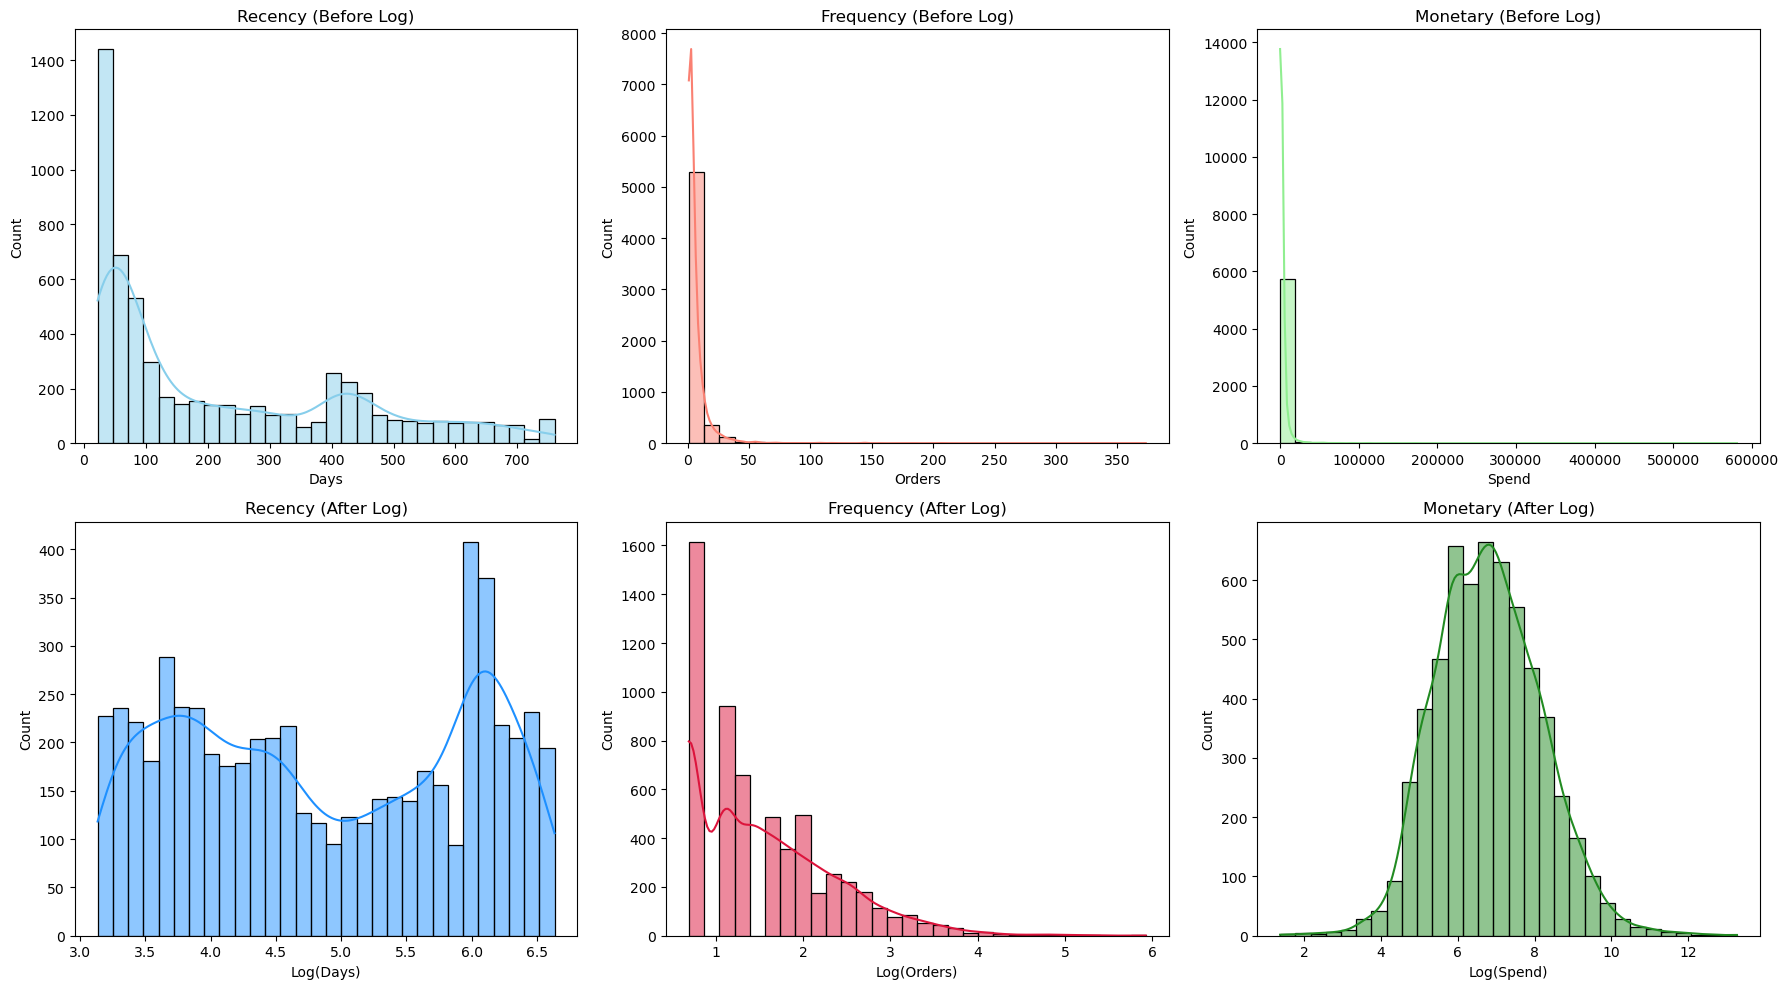

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# BEFORE LOG TRANSFORMATION
# Recency
sns.histplot(RFM['Recency'], bins=30, ax=axes[0, 0], color='skyblue', kde=True)
axes[0, 0].set_title('Recency (Before Log)')
axes[0, 0].set_xlabel('Days')

# Frequency
sns.histplot(RFM['Frequency'], bins=30, ax=axes[0, 1], color='salmon', kde=True)
axes[0, 1].set_title('Frequency (Before Log)')
axes[0, 1].set_xlabel('Orders')

# Monetary
sns.histplot(RFM['Monetary'], bins=30, ax=axes[0, 2], color='lightgreen', kde=True)
axes[0, 2].set_title('Monetary (Before Log)')
axes[0, 2].set_xlabel('Spend')

# Creating log columns using log(x + 1)
log_recency = np.log1p(RFM['Recency'])
log_frequency = np.log1p(RFM['Frequency'])
log_monetary = np.log1p(RFM['Monetary'])

# AFTER LOG TRANSFORMATION 
# Recency Log
sns.histplot(log_recency, bins=30, ax=axes[1, 0], color='dodgerblue', kde=True)
axes[1, 0].set_title('Recency (After Log)')
axes[1, 0].set_xlabel('Log(Days)')

# Frequency Log
sns.histplot(log_frequency, bins=30, ax=axes[1, 1], color='crimson', kde=True)
axes[1, 1].set_title('Frequency (After Log)')
axes[1, 1].set_xlabel('Log(Orders)')

# Monetary Log
sns.histplot(log_monetary, bins=30, ax=axes[1, 2], color='forestgreen', kde=True)
axes[1, 2].set_title('Monetary (After Log)')
axes[1, 2].set_xlabel('Log(Spend)')

plt.tight_layout()
plt.show()

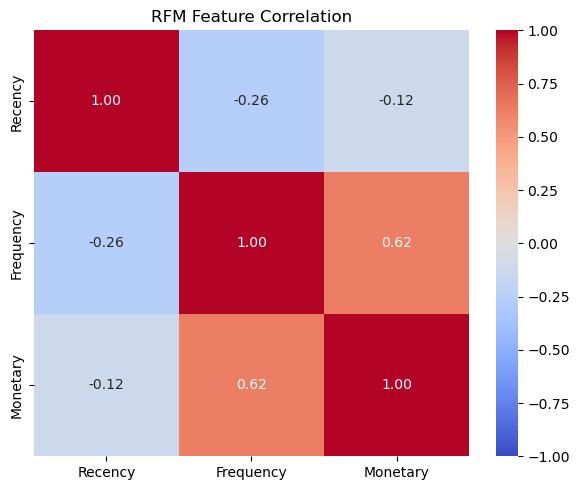

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(RFM.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=ax, vmin=-1, vmax=1)
ax.set_title('RFM Feature Correlation')
plt.tight_layout()


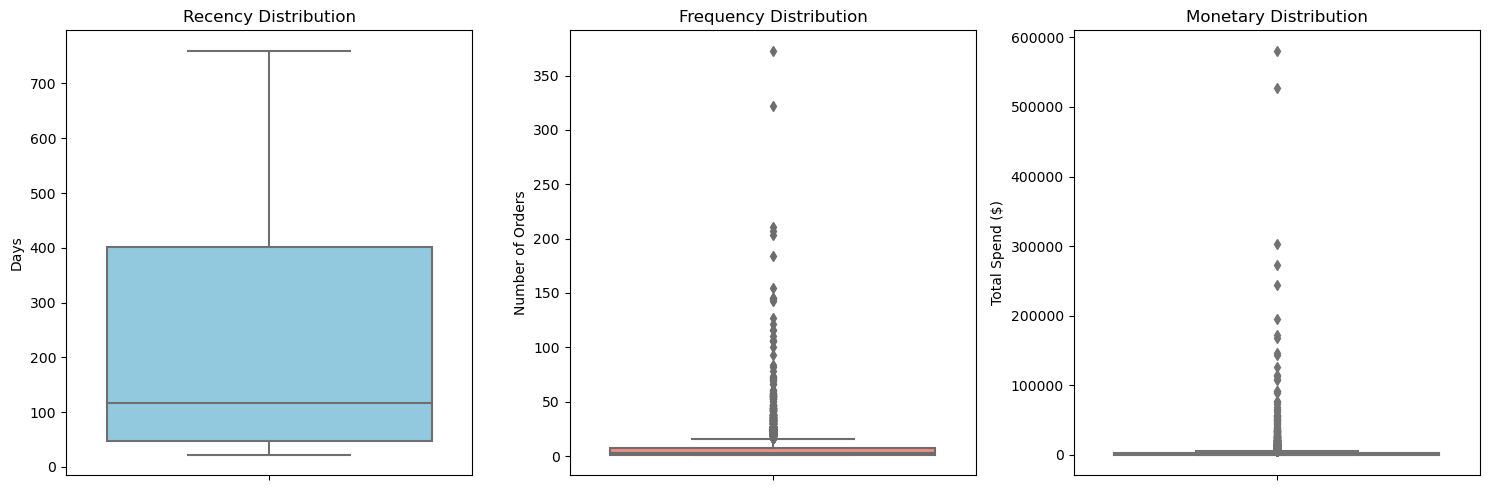

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Recency Boxplot
sns.boxplot(y=RFM['Recency'], ax=axes[0], color='skyblue')
axes[0].set_title('Recency Distribution')
axes[0].set_ylabel('Days')

# Frequency Boxplot
sns.boxplot(y=RFM['Frequency'], ax=axes[1], color='salmon')
axes[1].set_title('Frequency Distribution')
axes[1].set_ylabel('Number of Orders')

# Monetary Boxplot
sns.boxplot(y=RFM['Monetary'], ax=axes[2], color='lightgreen')
axes[2].set_title('Monetary Distribution')
axes[2].set_ylabel('Total Spend ($)')

plt.tight_layout()


## EDA Summary Report

### 1. Dataset Overview
- Clean dataset contains **776,059 transactions** from **5,846 unique customers**
- Three behavioral features engineered per customer — Recency, Frequency, Monetary
- Reference date for Recency calculation: **2012-01-01**

### 2. Feature Analysis

| Feature | Min | Max | Mean | Distribution |
|---|---|---|---|---|
| Recency | 2 days | 760 days | 221.66 days | Right-skewed |
| Frequency | 1 invoice | 373 invoices | 6.25 invoices | Heavily right-skewed |
| Monetary | £2.95 | £580,987 | £2,918.22 | Severely right-skewed |

### 3. Key Insights
- All three RFM features show heavy right-skewed distributions — particularly Monetary and Frequency — log transformation is essential before K-Means clustering
- Frequency and Monetary are positively correlated — customers who visit more naturally spend more — retention strategies targeting visit frequency will simultaneously drive revenue growth
- Boxplot analysis reveals two distinct outlier groups — super-loyal wholesale buyers (high frequency) and premium spenders (high monetary) — both retained as genuine behavioral segments
- Log transformation successfully normalized all three distributions — ensuring equal feature contribution to K-Means distance calculations

### 4. Feature Engineering Decisions
- **Kept all features** — Recency, Frequency and Monetary all carry independent behavioral signal
- **Retained high-value outliers** — extreme Frequency and Monetary values represent genuine wholesale and premium customer behavior — not data errors
- **Log transformation applied** — compresses skewed distributions without removing extreme values
- **StandardScaler applied** — normalizes scale across all three features — mean≈0, std≈1 confirmed

### 5. Business Recommendations From EDA
- Frequency is the key behavioral driver — customers who return more often naturally spend more — focus retention efforts on increasing visit frequency
- Two distinct high-value groups exist in the data — wholesale buyers and premium spenders — these should be treated as separate strategic segments
- 1,704 customers show high Recency values — they haven't purchased recently — representing an urgent at-risk population requiring immediate intervention


# 

## 5. Preprocessing

In [27]:
# Log Transform
rfm_log = RFM[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)
# Standard Scaler
scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(
    rfm_scaled_array, 
    columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'], 
    index=RFM.index )


In [28]:
rfm_scaled.head()

,Recency_scaled,Frequency_scaled,Monetary_scaled
Customer ID,,,
12346.0,0.896101,-0.199560,3.220752
12347.0,-1.525820,0.804212,1.226008
12348.0,-0.269399,0.302326,0.438582
12349.0,-1.070839,-0.199560,1.015282
12350.0,0.855578,-1.057540,-0.811229


In [29]:
rfm_scaled.describe()

,Recency_scaled,Frequency_scaled,Monetary_scaled
count,5.846000e+03,5.846000e+03,5.846000e+03
mean,2.673955e-17,-4.497106e-17,1.118199e-16
std,1.000086e+00,1.000086e+00,1.000086e+00
min,-1.602508e+00,-1.057540e+00,-3.935693e+00
25%,-9.258642e-01,-1.057540e+00,-7.077369e-01
50%,-1.025056e-01,-1.995603e-01,-3.929345e-02
75%,1.028770e+00,6.584195e-01,6.565839e-01
max,1.615718e+00,5.417543e+00,4.680900e+00


## Phase  Summary - Preprocessing

- Log transformation — compressed right-skewed distributions, reducing the influence of extreme values
- StandardScaler — normalized all features to mean≈0 and std≈1 — confirmed equal contribution to distance calculations

#### Result:
RFM features are scale-normalized and distribution-corrected — ready for K-Means clustering.

#

## 6. KMeans modeling

#### Elbow Method

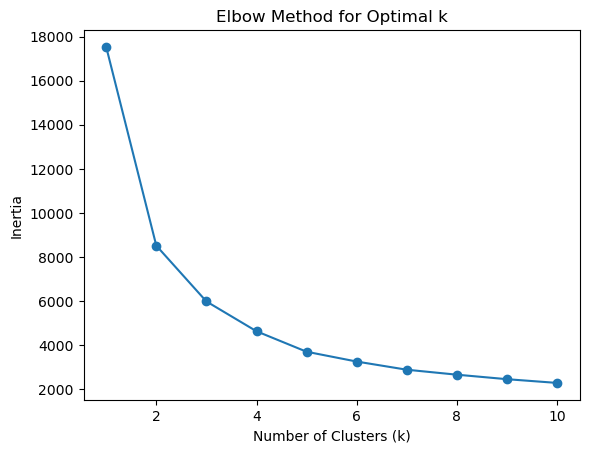

In [30]:
inertia = []
cluster_range = np.arange(1, 11)
for i in cluster_range:
    kmeans = KMeans(n_clusters=i, random_state=42 , n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    
plt.plot(cluster_range , inertia , marker = "o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

#### Silhouette score

For n_clusters = 2, Silhouette Score is: 0.4348
For n_clusters = 3, Silhouette Score is: 0.3801
For n_clusters = 4, Silhouette Score is: 0.3847
For n_clusters = 5, Silhouette Score is: 0.3665
For n_clusters = 6, Silhouette Score is: 0.3459
For n_clusters = 7, Silhouette Score is: 0.3239
For n_clusters = 8, Silhouette Score is: 0.2976
For n_clusters = 9, Silhouette Score is: 0.2818
For n_clusters = 10, Silhouette Score is: 0.2845


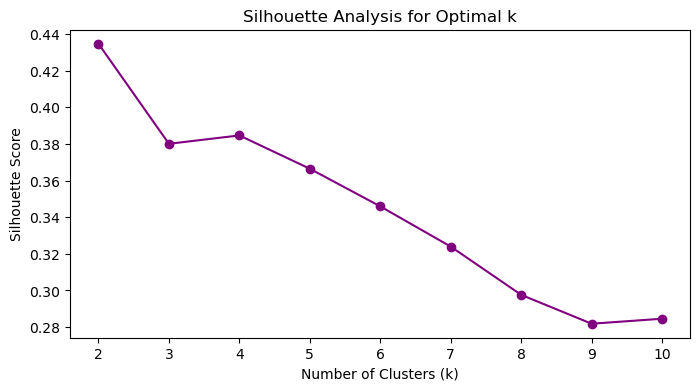

In [31]:
silhouette_scores = []
cluster_range = np.arange(2, 11)

for i in cluster_range:
    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"For n_clusters = {i}, Silhouette Score is: {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(cluster_range, silhouette_scores, marker='o', color='purple')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Optimal k")
plt.show()

## Phase  Summary — K-Means Modeling

- Elbow Method suggested K=4-5 as the point of diminishing returns
- Silhouette Score was highest at K=2 (0.4348) — but two segments offer insufficient business granularity
- K=4 achieved a Silhouette Score of 0.3847 — acceptable cluster quality — while providing four meaningful and interpretable business segments

#### Decision:
K=4 selected — balancing statistical validity with business interpretability. Four segments provide actionable marketing value that two segments cannot.


In [32]:
kmeans_final = KMeans(n_clusters=4, n_init=10, random_state=42)
rfm_log['Cluster'] = kmeans_final.fit_predict(rfm_scaled) +1

#

## 7. Cluster Analysis & Business Recommendation

In [33]:
cluster_counts = rfm_log['Cluster'].value_counts().sort_index()
cluster_means = rfm_log.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_summary = cluster_means.copy()
cluster_summary.insert(0, 'Customer Count', cluster_counts)
cluster_summary = cluster_summary.round(2)
cluster_summary

,Customer Count,Recency,Frequency,Monetary
Cluster,,,,
1,1704,6.02,0.82,5.44
2,1569,4.00,1.29,6.46
3,1358,3.84,2.68,8.56
4,1215,5.58,1.63,7.22


### Phase  Summary — Cluster Analysis

**What We Did:**
Analyzed the RFM centroid values of each cluster and assigned meaningful business labels.

**Cluster Profiles:**

| Cluster | Recency | Frequency | Monetary | Profile |
| :--- | :--- | :--- | :--- | :--- |
| **3 - Champions** | Lowest | Highest | Highest | Most recent, most frequent, highest spenders |
| **4 - Loyal Customers** | Moderate | Moderate | Good | Consistent buyers showing slight recency decline |
| **2 - Promising Customers** | Recent | Low | Moderate | Recent buyers with high conversion potential |
| **1 - At-Risk Customers** | Highest | Lowest | Lowest | Disengaged — longest since last purchase |

**Result:**
Business labels enable marketing teams to immediately understand each segment and act on recommendations — without requiring data science expertise.

---

### Business Recommendations

#### **Champions**
Launch an exclusive VIP program for Champion customers — offering early access to new products, premium discounts, and invitation-only events. This segment represents the highest business value and must be made to feel uniquely recognized. Increasing their switching costs through exclusivity ensures long-term retention and protects the most profitable customer relationships.

#### **Loyal Customers**
Deploy a personalized recommendation engine for Loyal Customers based on individual purchase history — delivering targeted communications featuring products aligned with their demonstrated preferences. The goal is to rebuild purchase frequency and reignite engagement before these customers drift toward the At-Risk segment.

#### **Promising Customers**
Introduce a loyalty points system where customers earn redeemable points for every purchase — exchangeable for free products or discounts upon reaching defined thresholds. This directly targets Promising Customers who demonstrate spending potential but lack the purchase frequency of Loyal Customers — incentivizing repeat visits and accelerating their progression up the loyalty ladder.

#### **At-Risk Customers**
Deploy an urgent win-back campaign for customers who have not purchased in over 100 days — combining time-sensitive discount offers with a short satisfaction survey to identify specific pain points driving disengagement. Early intervention at this stage is critical — customers who remain inactive beyond this window are significantly harder to recover and represent direct revenue loss.

#

## 8. PCA Visualization

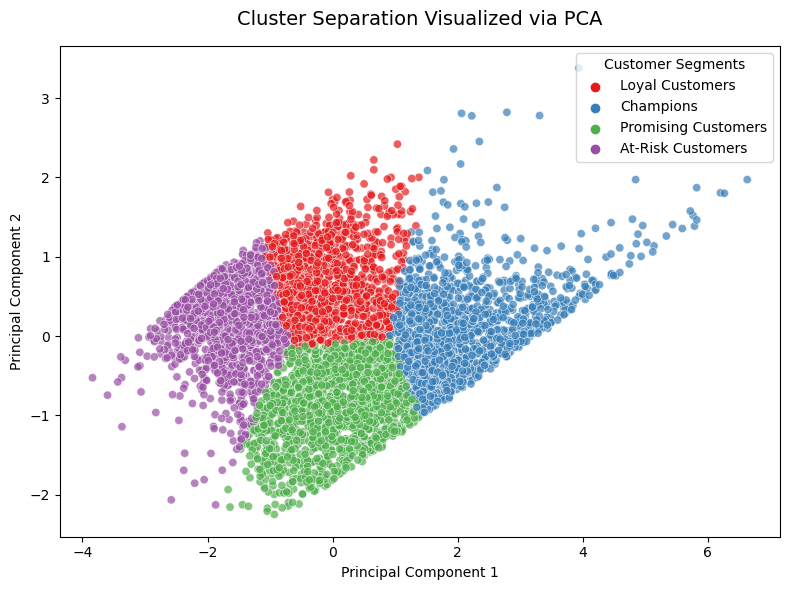

In [34]:
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)
pca_df = pd.DataFrame(rfm_pca, columns=['PCA Feature 1', 'PCA Feature 2'])
pca_df['Cluster'] = rfm_log['Cluster'].values

cluster_names = {
    1: 'At-Risk Customers',
    2: 'Promising Customers', 
    3: 'Champions',
    4: 'Loyal Customers'
}
pca_df['Segment'] = pca_df['Cluster'].map(cluster_names)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x='PCA Feature 1', 
    y='PCA Feature 2', 
    hue='Segment',
    data=pca_df, 
    palette='Set1', 
    alpha=0.7,
    ax=ax
)
ax.set_title('Cluster Separation Visualized via PCA', fontsize=14, pad=15)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(title='Customer Segments', loc='upper right')
plt.tight_layout()
plt.show()

In [35]:
print(pca.explained_variance_ratio_)

[0.7601876  0.19059067]


## Phase  Summary — PCA Visualization


- PC1 explains 76% of variance, PC2 explains 19% — together retaining 95% of the original RFM information — making the 2D visualization a highly reliable representation of actual cluster structure
- Four clusters are visually distinguishable with natural overlap in the center — expected behavior as real customer boundaries are rarely perfectly discrete
- Champions appear most distinctly separated — their unique combination of high Recency, Frequency and Monetary simultaneously places them far from all other segments in feature space

#### Result:
PCA confirms K=4 produces meaningful and separable customer segments — with 95% of behavioral information preserved in the visualization.

# 

## 9. Conclusion

### What We Built
This project built an unsupervised machine learning pipeline to segment 5,846 customers into four meaningful behavioral groups — uncovering hidden patterns in 776,059 retail transactions that raw data alone cannot reveal. The result enables marketing teams to move from generic campaigns to personalized strategies tailored to each customer's actual behavior.

### Customer Segments Discovered

| Segment | Profile | Business Priority |
|---|---|---|
| **Champions** | Most recent, most frequent, highest spenders | 🔴 Protect at all costs |
| **Loyal Customers** | Consistent buyers with slight recency decline | 🟡 Re-engage before they slip |
| **Promising Customers** | Recent buyers with high conversion potential | 🟡 Convert to loyal |
| **At-Risk Customers** | Disengaged — longest since last purchase | 🔴 Win back urgently |

### Key Findings
- Champions represent the highest business value — frequent buyers with the largest total spend — requiring exclusive VIP treatment to protect long-term retention
- At-Risk customers haven't purchased in over 100 days — requiring urgent win-back campaigns before they are permanently lost
- Frequency and Monetary are positively correlated — strategies that increase visit frequency naturally drive revenue growth
- Log transformation was essential — raw RFM distributions were heavily skewed and would have produced scale-driven clusters rather than behavioral ones

### Biggest Challenge
The absence of a target variable made this fundamentally different from supervised projects. Without a clear right or wrong answer — every decision required combining statistical evidence with business judgment — from choosing K=4 over K=2 despite lower Silhouette Score, to naming clusters in business language rather than technical labels.

### Limitations
- Dataset covers 2010-2011 — customer behavior may have shifted significantly since then
- RFM analysis uses only three dimensions — additional features like product category preferences or geographic patterns could enrich segmentation
- K-Means assumes spherical clusters — real customer segments may have more complex shapes

### Future Work
- [ ] Add radar chart visualization to profile each segment's RFM personality
- [ ] Incorporate product category data for richer customer profiling
- [ ] Build automated pipeline to re-segment customers monthly
- [ ] Deploy segmentation results into a live marketing dashboard
